In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


In [ ]:
train_path = os.path.join(path, "Training")
test_path = os.path.join(path, "Testing")

In [ ]:
print("Training Classes:")
print(os.listdir(train_path))

print("\nTesting Classes:")
print(os.listdir(test_path))

Training Classes:
['pituitary', 'notumor', 'meningioma', 'glioma']

Testing Classes:
['pituitary', 'notumor', 'meningioma', 'glioma']


In [ ]:
for folder in os.listdir(train_path):

    folder_path = os.path.join(train_path, folder)

    print(folder, ":", len(os.listdir(folder_path)), "images")

pituitary : 1400 images
notumor : 1400 images
meningioma : 1400 images
glioma : 1400 images


In [ ]:

import os
import glob
import socket
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------------- Cell: data generators ----------------
# preprocess_input (not rescale=1./255) is what actually matters for
# accuracy - ResNet50's imagenet weights expect this exact normalization.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_labels = list(train_generator.class_indices.keys())
print(train_generator.class_indices)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:

# ---------------- Cell: build model ----------------
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False   # freeze backbone for phase 1

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:

# ---------------- Cell: phase 1 - train the head ----------------
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7)

history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1120s 8s/step - accuracy: 0.8036 - loss: 0.6667 - val_accuracy: 0.8893 - val_loss: 0.2954 - learning_rate: 0.0010
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1050s 8s/step - accuracy: 0.8685 - loss: 0.4309 - val_accuracy: 0.9045 - val_loss: 0.2770 - learning_rate: 0.0010
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1053s 8s/step - accuracy: 0.8964 - loss: 0.3200 - val_accuracy: 0.8982 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1051s 8s/step - accuracy: 0.9009 - loss: 0.2734 - val_accuracy: 0.9286 - val_loss: 0.1963 - learning_rate: 0.0010
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1089s 8s/step - accuracy: 0.9094 - loss: 0.2544 - val_accuracy: 0.9250 - val_loss: 0.1877 - learning_rate: 0.0010
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1113s 8s/step - accuracy: 0.9208 - loss: 0.2147 - val_accuracy: 0.9205 - val_loss: 0.2138 - learning_rate: 0.0010
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1112s 8s/step - accuracy: 0.9230 - l

In [ ]:

# ---------------- Cell: phase 2 - fine-tune ResNet50 ----------------
# unfreeze the last block of ResNet50 and train with a low LR - this
# is what pushes accuracy from "good" to "high"
base_model.trainable = True
for layer in base_model.layers[:143]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1496s 11s/step - accuracy: 0.9317 - loss: 0.1818 - val_accuracy: 0.9411 - val_loss: 0.1684 - learning_rate: 1.0000e-05
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1629s 12s/step - accuracy: 0.9435 - loss: 0.1477 - val_accuracy: 0.9455 - val_loss: 0.1626 - learning_rate: 1.0000e-05
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1473s 11s/step - accuracy: 0.9545 - loss: 0.1276 - val_accuracy: 0.9545 - val_loss: 0.1367 - learning_rate: 1.0000e-05
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1475s 11s/step - accuracy: 0.9587 - loss: 0.1020 - val_accuracy: 0.9518 - val_loss: 0.1338 - learning_rate: 1.0000e-05
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1465s 10s/step - accuracy: 0.9681 - loss: 0.0873 - val_accuracy: 0.9527 - val_loss: 0.1490 - learning_rate: 1.0000e-05
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1470s 11s/step - accuracy: 0.9701 - loss: 0.0800 - val_accuracy: 0.9509 - val_loss: 0.1399 - learning_rate: 1.0000e-05
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1517s 

50/50 ━━━━━━━━━━━━━━━━━━━━ 310s 6s/step - accuracy: 0.9350 - loss: 0.5613
Test Loss: 0.5613  |  Test Accuracy: 0.9350
50/50 ━━━━━━━━━━━━━━━━━━━━ 341s 7s/step
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.87      0.94      0.91       400
     notumor       0.95      1.00      0.97       400
   pituitary       0.95      1.00      0.97       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.93      1600
weighted avg       0.94      0.94      0.93      1600



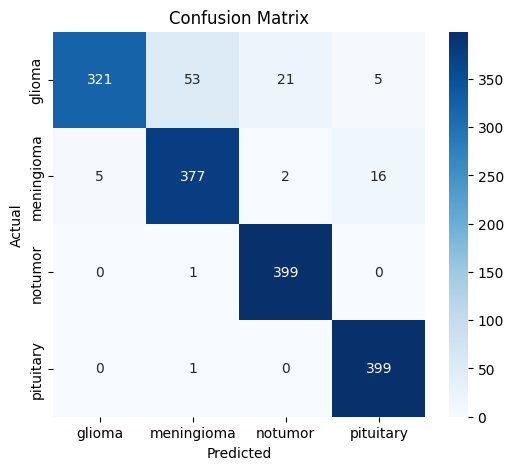

In [ ]:

# ---------------- Cell: evaluate ----------------
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

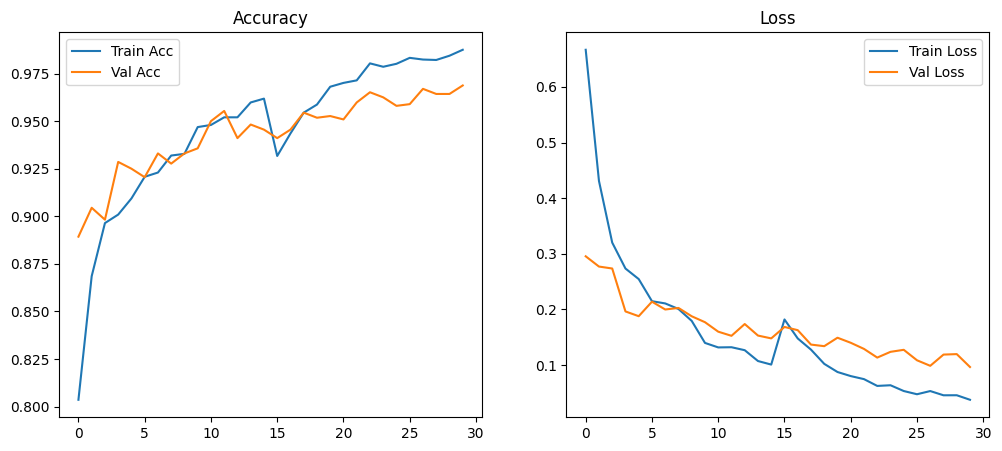

In [ ]:

# ---------------- Cell: accuracy / loss curves ----------------
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Acc'); plt.plot(val_acc, label='Val Acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss'); plt.plot(val_loss, label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()

In [ ]:
model.save("brain_tumor_resnet50.keras")

In [ ]:
import os
print(os.path.exists("brain_tumor_resnet50.keras"))

True


In [ ]:
from google.colab import files
files.download("brain_tumor_resnet50.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =================================================================
# Brain Tumor MRI Classification - Vision Transformer (ViT-B/16)
# Google Colab. 4 classes: glioma, meningioma, notumor, pituitary
#
# NOTE: this uses PyTorch + Hugging Face `transformers` instead of
# vit-keras. vit-keras is unmaintained and hard-depends on
# tensorflow_addons, which is discontinued and has no wheels for
# current Python/TensorFlow versions - that's the
# "ModuleNotFoundError: No module named 'tensorflow_addons'" you hit,
# and installing tfa manually would just fail the same way.
# transformers + PyTorch is the reliable, actively-maintained path
# for fine-tuning a pretrained ViT, and Colab ships PyTorch by
# default, so nothing fragile to install here.
# =================================================================

!pip install -q transformers kagglehub

import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
MODEL_NAME = "google/vit-base-patch16-224-in21k"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:

# ---------------- Cell: transforms + datasets ----------------
# mean/std that ViT's pretrained weights expect - same role
# preprocess_input played for ResNet50/VGG16. Pulled straight from
# the model's own processor so it always matches the checkpoint.
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
mean, std = processor.image_mean, processor.image_std

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

full_train = datasets.ImageFolder(train_path, transform=train_transform)
class_labels = full_train.classes
print(full_train.class_to_idx)

val_frac = 0.2
val_size = int(val_frac * len(full_train))
train_size = len(full_train) - val_size
train_ds, val_ds = torch.utils.data.random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
# ImageFolder lists files in a deterministic sorted order, so the
# same split indices line up with a freshly-loaded copy - swap that
# copy in for validation so it doesn't get train-time augmentation.
val_ds.dataset = datasets.ImageFolder(train_path, transform=eval_transform)

test_ds = datasets.ImageFolder(test_path, transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [ ]:
# ---------------- Cell: build model ----------------
model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label={i: c for i, c in enumerate(class_labels)},
    label2id={c: i for i, c in enumerate(class_labels)},
    ignore_mismatched_sizes=True
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.bias   | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.weight          | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.bias   | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.weight   | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.b

In [ ]:
 #---------------- Cell: train / eval helpers ----------------
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(pixel_values=images).logits
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total


def fit(model, train_loader, val_loader, epochs, lr, patience=5):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.3, patience=3
    )
    best_val_loss, best_state, no_improve = float('inf'), None, 0
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader)
        scheduler.step(val_loss)

        history['loss'].append(train_loss); history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss); history['val_accuracy'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss, best_state, no_improve = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    return history


In [ ]:
for p in model.vit.parameters():
    p.requires_grad = False
for p in model.classifier.parameters():
    p.requires_grad = True

history1 = fit(model, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 - loss: 1.2575 - acc: 0.4632 - val_loss: 1.1619 - val_acc: 0.5652
Epoch 2/10 - loss: 1.1665 - acc: 0.5359 - val_loss: 1.1301 - val_acc: 0.5946
Epoch 3/10 - loss: 1.1403 - acc: 0.5748 - val_loss: 1.1150 - val_acc: 0.6009
Epoch 4/10 - loss: 1.1215 - acc: 0.5781 - val_loss: 1.1035 - val_acc: 0.5705
Epoch 5/10 - loss: 1.1124 - acc: 0.5844 - val_loss: 1.0930 - val_acc: 0.6429
Epoch 6/10 - loss: 1.1028 - acc: 0.5866 - val_loss: 1.0732 - val_acc: 0.6348
Epoch 7/10 - loss: 1.0983 - acc: 0.5942 - val_loss: 1.0739 - val_acc: 0.6420
Epoch 8/10 - loss: 1.0981 - acc: 0.5886 - val_loss: 1.0637 - val_acc: 0.6188
Epoch 9/10 - loss: 1.0906 - acc: 0.5960 - val_loss: 1.0623 - val_acc: 0.5946
Epoch 10/10 - loss: 1.0841 - acc: 0.6020 - val_loss: 1.0493 - val_acc: 0.6268


In [ ]:
# ---------------- Cell: phase 2 - fine-tune the full model ----------------
# unfreeze the transformer backbone, continue at a much lower LR -
# this is what pushes ViT from "decent" to matching your ResNet50/
# VGG16 accuracy
for p in model.vit.parameters():
    p.requires_grad = True

history2 = fit(model, train_loader, val_loader, epochs=15, lr=2e-5)


Epoch 1/15 - loss: 1.2691 - acc: 0.5210 - val_loss: 1.0856 - val_acc: 0.5795
Epoch 2/15 - loss: 0.9833 - acc: 0.6549 - val_loss: 0.8680 - val_acc: 0.7018
Epoch 3/15 - loss: 0.8611 - acc: 0.7246 - val_loss: 0.7725 - val_acc: 0.7821
Epoch 4/15 - loss: 0.7621 - acc: 0.7837 - val_loss: 0.7066 - val_acc: 0.8241
Epoch 5/15 - loss: 0.7046 - acc: 0.8087 - val_loss: 0.6490 - val_acc: 0.8455
Epoch 6/15 - loss: 0.6681 - acc: 0.8304 - val_loss: 0.6158 - val_acc: 0.8732
Epoch 7/15 - loss: 0.6418 - acc: 0.8467 - val_loss: 0.6555 - val_acc: 0.8366
Epoch 8/15 - loss: 0.6166 - acc: 0.8607 - val_loss: 0.5870 - val_acc: 0.8821
Epoch 9/15 - loss: 0.5985 - acc: 0.8712 - val_loss: 0.5966 - val_acc: 0.8804


Test Loss: 1.2797  |  Test Accuracy: 0.5744
              precision    recall  f1-score   support

      glioma       0.55      0.54      0.54       400
  meningioma       0.42      0.26      0.32       400
     notumor       0.71      0.70      0.71       400
   pituitary       0.56      0.80      0.66       400

    accuracy                           0.57      1600
   macro avg       0.56      0.57      0.56      1600
weighted avg       0.56      0.57      0.56      1600



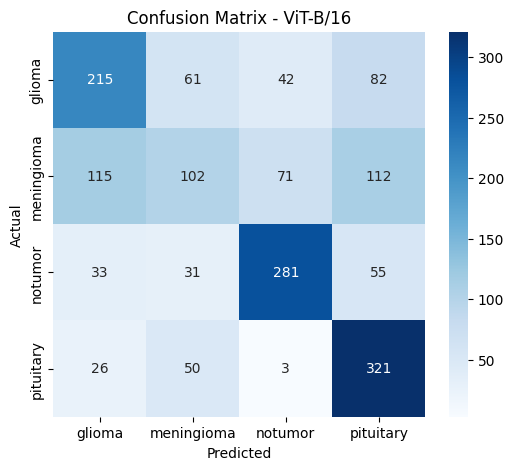

In [ ]:

# ---------------- Cell: evaluate on test set ----------------
test_loss, test_acc = run_epoch(model, test_loader)
print(f"Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}")

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(pixel_values=images.to(device)).logits
        y_pred.extend(logits.argmax(1).cpu().numpy())
        y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - ViT-B/16")
plt.show()

In [ ]:
acc = history1['accuracy'] + history2['accuracy']
val_acc = history1['val_accuracy'] + history2['val_accuracy']
loss = history1['loss'] + history2['loss']
val_loss = history1['val_loss'] + history2['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Acc'); plt.plot(val_acc, label='Val Acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss'); plt.plot(val_loss, label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()


NameError: name 'history2' is not defined

In [ ]:
model.save_pretrained("/content/brain_tumor_vit_b16")